In [1]:
import pickle
import pandas as pd
import h5py
import numpy as np
from pathlib import Path
import re
from typing import List, Dict, Optional, Tuple, Iterable
from sklearn.decomposition import FastICA
from dataclasses import dataclass

sessionTable = {
    "rBWrl003": ["1208_s0", "1209_s1", "1210_s1", "1211_s1", "1213_s1", "1214_s1", "1215_s0", "1216_s1"],
    "rBWrl004": ["1209_s1", "1210_s1", "1211_s1", "1213_s1", "1214_s0", "1216_s0"],
    "rBWrl005": ["1209_s1", "1210_s1", "1211_s1", "1213_s1", "1214_s0", "1215_s0", "1216_s0", "1217_s0"]
}

def load_session_spikes(base_dir: str, rat: str, session: str):
    """
    Load one session's spike-time dict.
    Returns:
        spkdataSession: dict with keys "mPFC", "vlOFC"
                        spkdataSession["mPFC"] is a dict:
                            unit_id -> np.ndarray of spike times (sec)
    """
    fnameBase = f"{rat}_{session}"
    pkl_path = Path(base_dir) / f"{fnameBase}_spktimes.pkl"
    with open(pkl_path, 'rb') as f:
        spkdataSession = pickle.load(f)
    return spkdataSession

unit_pattern = re.compile(r"shank(\d+)_unit(\d+)$")

def parse_unit_id(unit_id: str):
    """
    Extract numeric shank and unit values robustly from strings like:
      shank1_unit7
      shank2_unit10
      shank3_unit003
    Returns (shank:int, unit:int)
    """
    m = unit_pattern.match(unit_id)
    if m is None:
        raise ValueError(f"Could not parse unit ID: {unit_id}")
    return int(m.group(1)), int(m.group(2))


def sort_unit_ids(unit_ids):
    """
    Sort using numeric (shank, unit) ordering.
    """
    return sorted(unit_ids, key=lambda uid: parse_unit_id(uid))

In [2]:
def find_common_units_for_rat(
    base_dir: str,
    rat: str,
    sessionTable: Dict[str, Iterable[str]],
    regions=("mPFC", "vlOFC"),
):
    """
    For a given rat, find unit IDs that are present in *all* its sessions,
    separately for each region.

    Returns:
        common_units_rat: dict, e.g.
            {
                "mPFC": set([...]),
                "vlOFC": set([...]),
            }
    """
    sessions = sessionTable[rat]

    # Will accumulate intersections here
    common_per_region: Dict[str, Set[str]] = {reg: None for reg in regions}

    for sess in sessions:
        spkdataSession = load_session_spikes(base_dir, rat, sess)

        for reg in regions:
            unit_ids = set(spkdataSession[reg].keys())
            if common_per_region[reg] is None:
                common_per_region[reg] = unit_ids
            else:
                common_per_region[reg] &= unit_ids

    # Replace any None with empty set for safety
    for reg in regions:
        if common_per_region[reg] is None:
            common_per_region[reg] = set()

    return common_per_region


In [3]:
rat = "rBWrl005"
base_dir = "/Users/zhehanfu/data/session_data"
common_units_rat = find_common_units_for_rat(base_dir, rat, sessionTable)
common_units_sorted = {
    reg: sort_unit_ids(common_units_rat[reg])
    for reg in ["mPFC", "vlOFC"]
}

/var/folders/hy/p883vxwd3mb5y2tbvnrslsgr0000gn/T/ipykernel_20214/2263335452.py:28: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  spkdataSession = pickle.load(f)


In [4]:
def bin_spike_times_for_epoch(
    spkdata_region: dict,
    unit_order: list,
    align_times: np.ndarray,
    epoch_window=(-1.0, 0.0),
    bin_size=0.05
):
    """
    Convert spike times into neuron × time × trial binned counts.

    Args:
        spkdata_region: dict {unit_id -> array of spike times (sec)}
        unit_order: list of unit IDs in desired order
        align_times: array of length n_trials, times of alignment event
        epoch_window: (start, end) relative to align_times
        bin_size: width of each bin (sec)

    Returns:
        X: np.ndarray of shape (n_units, n_bins, n_trials)
    """
    n_units = len(unit_order)
    n_trials = len(align_times)

    start, end = epoch_window
    bin_edges = np.arange(start, end + 1e-12, bin_size)
    n_bins = len(bin_edges) - 1

    X = np.zeros((n_units, n_bins, n_trials), dtype=np.float32)

    for ui, unit_id in enumerate(unit_order):
        spk_times = spkdata_region[unit_id]
        for ti, t_align in enumerate(align_times):
            # shift spikes into trial-relative time
            rel_times = spk_times - t_align
            mask = (rel_times >= start) & (rel_times <= end)
            rel_t = rel_times[mask]
            counts, _ = np.histogram(rel_t, bins=bin_edges)
            X[ui, :, ti] = counts

    return X

In [5]:
def compute_next_trial_labels(trialtable_full, ids_matched_trial):
    choices_full = trialtable_full.choice.values.astype(int)
    certainty_full = np.abs(trialtable_full.pLbetter.values - 0.5)

    # next trial labels in FULL table
    next_choice_full = np.full(choices_full.shape, -1, dtype=int)
    next_choice_full[:-1] = choices_full[1:]

    next_cert_full = np.full(certainty_full.shape, -1.0, dtype=float)
    next_cert_full[:-1] = certainty_full[1:]

    # map into the valid-trial space
    next_choice_valid = next_choice_full[ids_matched_trial].copy()
    next_cert_valid   = next_cert_full[ids_matched_trial].copy()

    # mark last valid trial invalid if it corresponds to last full trial
    if ids_matched_trial[-1] == len(choices_full) - 1:
        next_choice_valid[-1] = -1
        next_cert_valid[-1]   = -1.0

    return next_choice_valid, next_cert_valid



def build_session_concatenated_X(
    base_dir: str,
    rat: str,
    sessionTable: dict,
    common_units_sorted: dict,
    align_event: str,
    srate: float = 20000,
    epoch_window=(-1.0, 0.0),
    bin_size=0.05,
    regions=("mPFC", "vlOFC"),
):

    sessions = sessionTable[rat]

    X_concat = {reg: [] for reg in regions}
    choices_all = []
    next_choices_all = []
    outcomes_all = []
    certainty_all = []
    next_certainty_all = []
    session_ids = []
    trial_index_map = []

    for sess_idx, session in enumerate(sessions):

        fnameBase = f"{rat}_{session}"

        # ----- Load spike times -----
        with open(Path(base_dir) / f"{fnameBase}_spktimes.pkl", "rb") as f:
            spkdataSession = pickle.load(f)

        # ----- Load trial tables -----
        trialtable_full  = pd.read_pickle(Path(base_dir) / f"{fnameBase}_trialtable_full_RFLRExt.pkl")
        trialtable_valid = pd.read_pickle(Path(base_dir) / f"{fnameBase}_trialtable_valid.pkl")

        go_full  = trialtable_full["go_cue"].values
        go_valid = trialtable_valid["go_cue"].values

        # match full ↔ valid trial indices
        ids_matched_trial = np.array([int(np.where(go_full == t)[0][0]) for t in go_valid])

        # ----- Behavioral labels -----
        choices_valid  = trialtable_valid.choice.values.astype(int)
        outcomes_valid = trialtable_valid.outcome.values.astype(int)

        certainty_full = np.abs(trialtable_full.pLbetter.values - 0.5)
        certainty_valid = certainty_full[ids_matched_trial]

        next_choice_valid, next_cert_valid = compute_next_trial_labels(
            trialtable_full, ids_matched_trial
        )

        # ----- Alignment times -----
        align_times = trialtable_valid[align_event].values / srate
        if np.isnan(align_times).any():
            raise ValueError(f"NaN in alignment times for session {session}")

        n_trials = len(align_times)
        trial_index_map.append(np.arange(len(session_ids), len(session_ids) + n_trials))

        # ----- Build X for each region -----
        for reg in regions:
            unit_order = common_units_sorted[reg]
            n_units = len(unit_order)

            # (n_units, 20, n_trials)
            X_reg = bin_spike_times_for_epoch(
                spkdata_region=spkdataSession[reg],
                unit_order=unit_order,
                align_times=align_times,
                epoch_window=epoch_window,
                bin_size=bin_size
            )

            # --- Within-session z-score ---
            X_flat = X_reg.reshape(n_units, -1)
            mu = X_flat.mean(axis=1, keepdims=True)
            sd = X_flat.std(axis=1, keepdims=True) + 1e-9
            Xz = (X_flat - mu) / sd
            Xz = Xz.reshape(n_units, X_reg.shape[1], X_reg.shape[2])

            X_concat[reg].append(Xz)

        # ----- Append behavior -----
        choices_all.append(choices_valid)
        next_choices_all.append(next_choice_valid)
        outcomes_all.append(outcomes_valid)
        certainty_all.append(certainty_valid)
        next_certainty_all.append(next_cert_valid)
        session_ids.append(np.full(n_trials, sess_idx, dtype=int))

    # ----- Final concatenation -----
    for reg in regions:
        X_concat[reg] = np.concatenate(X_concat[reg], axis=2)

    choices_all       = np.concatenate(choices_all)
    next_choices_all  = np.concatenate(next_choices_all)
    outcomes_all      = np.concatenate(outcomes_all)
    certainty_all     = np.concatenate(certainty_all)
    next_certainty_all= np.concatenate(next_certainty_all)
    session_ids       = np.concatenate(session_ids)

    return (
        X_concat,
        choices_all,
        next_choices_all,
        outcomes_all,
        certainty_all,
        next_certainty_all,
        session_ids,
        trial_index_map
    )

In [6]:
X_concat, choices_all, next_choices_all, outcomes_all, certainty_all, next_certainty_all, session_ids, trial_index_map = (
    build_session_concatenated_X(
        base_dir      = base_dir,
        rat           = rat,
        sessionTable  = sessionTable,
        common_units_sorted = common_units_sorted,
        align_event   = "nose_out_reward_port",
        epoch_window  = (-1.0, 0.0),
        bin_size      = 0.05,
    )
)

/var/folders/hy/p883vxwd3mb5y2tbvnrslsgr0000gn/T/ipykernel_20214/3014420125.py:54: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  spkdataSession = pickle.load(f)
/var/folders/hy/p883vxwd3mb5y2tbvnrslsgr0000gn/T/ipykernel_20214/3014420125.py:54: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-wo

In [7]:
def reshape_region_to_matrix(X_region):
    # X_region: (n_units, 20, total_trials)
    n_units, n_bins, n_trials = X_region.shape
    return X_region.reshape(n_units, n_bins * n_trials)

X_mPFC_mat  = reshape_region_to_matrix(X_concat["mPFC"])   # (N_m, 20*T)
X_vlOFC_mat = reshape_region_to_matrix(X_concat["vlOFC"])  # (N_v, 20*T)

X_all = np.vstack([X_mPFC_mat, X_vlOFC_mat])

n_m = X_mPFC_mat.shape[0]
n_v = X_vlOFC_mat.shape[0]

neuron_region = np.array(
    ["mPFC"] * n_m + ["vlOFC"] * n_v
)

In [8]:
@dataclass
class EnsembleResult:
    weights: np.ndarray          # (n_neurons, n_ensembles) assembly weight vectors
    memberships: List[np.ndarray]# list of 1D arrays with neuron indices per ensemble
    activities_linear: np.ndarray      # (n_ensembles, n_bins) ICA sources
    activities_quadratic: np.ndarray   # (n_ensembles, n_bins) quadratic R_k(t)
    eigenvalues: np.ndarray      # all eigenvalues of the correlation matrix (sorted desc)
    mp_lambda_max: float         # Marchenko–Pastur upper edge used for PC selection

def marcenko_pastur_upper_edge(n_neurons: int, n_bins: int) -> float:
    """
    MP upper edge for the eigenvalues of a correlation matrix of
    n_neurons variables with n_bins samples (unit variance case).
    λ_max = (1 + sqrt(gamma))^2 with gamma = n_neurons / n_bins.  [oai_citation:1‡Wikipedia](https://en.wikipedia.org/wiki/Marchenko%E2%80%93Pastur_distribution)
    """
    gamma = n_neurons / n_bins
    return (1.0 + np.sqrt(gamma))**2

def run_ica_on_pcs(Xz: np.ndarray,
                   evecs_sig: np.ndarray,
                   n_components: int,
                   random_state: Optional[int] = 0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Xz: (n_neurons, n_bins), z-scored
    evecs_sig: (n_neurons, k), eigenvectors of significant PCs
    n_components: number of ICA components (usually k)
    Returns:
        U: (n_neurons, n_components) assembly weight vectors in neuron space
        S: (n_components, n_bins) independent component time courses
    """
    # project data onto significant PC subspace
    # Z: (k, n_bins)
    Z = evecs_sig.T @ Xz

    # ICA expects (n_samples, n_features): here (n_bins, k)
    ica = FastICA(
        n_components=n_components,
        whiten="unit-variance",
        max_iter=1000,
        random_state=random_state
    )
    S = ica.fit_transform(Z.T)     # (n_bins, n_components)
    W = ica.components_           # (n_components, k) unmixing matrix

    # bring components back to neuron space: U = E_sig * W^T
    U = evecs_sig @ W.T           # (n_neurons, n_components)

    # make sign conventions consistent (largest |weight| positive)
    for j in range(U.shape[1]):
        col = U[:, j]
        if np.abs(col.min()) > np.abs(col.max()):
            U[:, j] = -col
            S[:, j] = -S[:, j]

    return U, S.T  # S.T: (n_components, n_bins)

def compute_null_weight_threshold(
    X: np.ndarray,
    n_shuffles: int,
    weight_percentile: float = 99.0,
    random_state: Optional[int] = 0
) -> float:
    """
    Build a null distribution of absolute weights by circularly shifting
    each neuron's spike train in time, then running PCA+ICA on the shuffled data.
    Returns a single global threshold = percentile of |weights|.
    (Lopes-dos-Santos style null.  [oai_citation:2‡PubMed](https://pubmed.ncbi.nlm.nih.gov/21698248/)

    X: (n_neurons, n_bins) raw counts
    """
    rng = np.random.default_rng(random_state)
    n_neurons, n_bins = X.shape
    all_abs_weights = []

    for s in range(n_shuffles):
        # circularly shift each neuron independently
        shifts = rng.integers(0, n_bins, size=n_neurons)
        X_shuff = np.empty_like(X)
        for i in range(n_neurons):
            X_shuff[i] = np.roll(X[i], shifts[i])

        Xz_shuff = zscore_neurons(X_shuff)
        evals, evecs = pca_from_correlation(Xz_shuff)
        k, _ = select_significant_pcs_mp(evals, n_neurons, n_bins)
        if k == 0:
            continue
        evecs_sig = evecs[:, :k]  # evals already sorted desc

        U_shuff, _ = run_ica_on_pcs(Xz_shuff, evecs_sig, n_components=k,
                                    random_state=rng.integers(1e9))
        all_abs_weights.append(np.abs(U_shuff).ravel())

    if not all_abs_weights:
        # fallback: if MP finds no PCs in shuffled data
        return np.inf

    all_abs_weights = np.concatenate(all_abs_weights)
    return np.percentile(all_abs_weights, weight_percentile)

def compute_quadratic_activities(U: np.ndarray, Z: np.ndarray) -> np.ndarray:
    """
    Compute quadratic-form ensemble activation:
        R_k(t) = (v_k^T z(t))^2 - sum_i (v_{ik}^2 * z_i(t)^2)
    for each ensemble k and time t.

    Args:
        U: (n_neurons, n_ensembles) weight matrix (columns = v_k)
        Z: (n_neurons, n_bins) z-scored firing rates z(t)

    Returns:
        R: (n_ensembles, n_bins) quadratic activation R_k(t)
    """
    # Projection term: y_k(t) = v_k^T z(t)
    Y = U.T @ Z  # (n_ensembles, n_bins)

    # Self-term due to diagonal subtraction
    V2 = U**2             # (n_neurons, n_ensembles)
    Z2 = Z**2             # (n_neurons, n_bins)
    self_term = V2.T @ Z2 # (n_ensembles, n_bins)

    # Quadratic form with zeroed diagonal
    return Y**2 - self_term

def detect_ensembles_pca_ica(
    Xz: np.ndarray,               # (n_neurons, n_timebins) ALREADY Z-SCORED
    n_shuffles_null: int = 0,
    null_weight_percentile: float = 99.0,
    membership_sd: float = 1.0,   # NEW: mean + 1*SD membership rule
    min_members: int = 2,
    random_state: int = 0
):
    """
    PCA–ICA ensemble detection on ALREADY Z-SCORED activity.

    Args:
        Xz: Already z-scored activity, (n_neurons, n_timebins)
        membership_sd: scalar — membership threshold = mean(|v|) + membership_sd * std(|v|)
        All other arguments: same as before.

    Returns:
        EnsembleResult(...) with weights, memberships, activities, etc.
    """

    rng = np.random.default_rng(random_state)
    n_neurons, n_bins = Xz.shape

    # -------- PCA on correlation matrix --------
    C = np.corrcoef(Xz)
    evals, evecs = np.linalg.eigh(C)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    # significant PCs via MP bound
    lambda_max_mp = marcenko_pastur_upper_edge(n_neurons, n_bins)
    k = int(np.sum(evals > lambda_max_mp))

    if k == 0:
        # no ensembles detected
        return EnsembleResult(
            weights=np.zeros((n_neurons, 0)),
            memberships=[],
            activities_linear=np.zeros((0, n_bins)),
            activities_quadratic=np.zeros((0, n_bins)),
            eigenvalues=evals,
            mp_lambda_max=lambda_max_mp
        )

    evecs_sig = evecs[:, :k]

    # -------- ICA --------
    U, S = run_ica_on_pcs(
        Xz,
        evecs_sig,
        n_components=k,
        random_state=int(rng.integers(1e9))
    )
    # U: (n_neurons, k) weights
    # S: (k, n_bins) ICA time courses

    # -------- Null-based global threshold (optional) --------
    if n_shuffles_null > 0:
        weight_thr = compute_null_weight_threshold(
            Xz,
            n_shuffles=n_shuffles_null,
            weight_percentile=null_weight_percentile,
            random_state=int(rng.integers(1e9))
        )

        # membership based on v > weight_thr
        memberships = [
            np.where(np.abs(U[:, j]) > weight_thr)[0]
            for j in range(U.shape[1])
        ]

    else:
        # -------- mean + 1*SD weight rule --------
        memberships = []
        for j in range(U.shape[1]):
            w = U[:, j]
            thr = w.mean() + membership_sd * w.std()
            idx = np.where(w > thr)[0]
            memberships.append(idx)

    # discard ensembles with < min_members
    keep = [i for i, mem in enumerate(memberships) if len(mem) >= min_members]
    U_keep = U[:, keep]
    S_keep = S[keep, :]
    memberships_keep = [memberships[i] for i in keep]

    # -------- Quadratic-form ensemble activity --------
    activities_quad = compute_quadratic_activities(U_keep, Xz)

    return EnsembleResult(
        weights=U_keep,
        memberships=memberships_keep,
        activities_linear=S_keep,
        activities_quadratic=activities_quad,
        eigenvalues=evals,
        mp_lambda_max=lambda_max_mp
    )

In [9]:
result = detect_ensembles_pca_ica(
    X_all,
    membership_sd = 1.0,          # mean + 1 SD membership rule
    n_shuffles_null = 0,          # disable null-based threshold for now
    min_members = 2,              # must have ≥2 neurons per ensemble
    random_state = 42
)

In [10]:
import h5py
import numpy as np

def save_pca_ica_results_h5(
    filepath,
    X_all,
    common_units_sorted,
    choices_all,
    next_choices_all,
    outcomes_all,
    certainty_all,
    next_certainty_all,
    session_ids,
    trial_index_map,
    result,
    epoch_window,
    bin_size,
    alignment_event
):

    start, end = epoch_window
    n_bins = int(round((end - start) / bin_size))
    bin_edges = np.linspace(start, end, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    with h5py.File(filepath, "w") as f:

        # ---------- DATA ----------
        f.create_dataset("X_all", data=X_all, compression="gzip")

        # ---------- COMMON UNITS ----------
        grp_units = f.create_group("common_units_sorted")
        dt = h5py.string_dtype(encoding="utf-8")
        for region, units in common_units_sorted.items():
            grp_units.create_dataset(region, data=np.array(units, dtype=dt))

        # ---------- BEHAVIOR ----------
        grp_beh = f.create_group("behavior")
        grp_beh.create_dataset("choices_all", data=choices_all)
        grp_beh.create_dataset("next_choices_all", data=next_choices_all)
        grp_beh.create_dataset("outcomes_all", data=outcomes_all)
        grp_beh.create_dataset("certainty_all", data=certainty_all)
        grp_beh.create_dataset("next_certainty_all", data=next_certainty_all)
        grp_beh.create_dataset("session_ids", data=session_ids)

        grp_tim = grp_beh.create_group("trial_index_map")
        for i, arr in enumerate(trial_index_map):
            grp_tim.create_dataset(f"session_{i}", data=np.asarray(arr, dtype=int))

        # ---------- ENSEMBLES ----------
        grp_ens = f.create_group("ensembles")
        grp_ens.create_dataset("weights", data=result.weights)
        grp_ens.create_dataset("activities_linear", data=result.activities_linear)
        grp_ens.create_dataset("activities_quadratic", data=result.activities_quadratic)
        grp_ens.create_dataset("eigenvalues", data=result.eigenvalues)
        grp_ens.create_dataset("mp_lambda_max", data=np.array(result.mp_lambda_max))

        grp_mem = grp_ens.create_group("memberships")
        for k, arr in enumerate(result.memberships):
            grp_mem.create_dataset(
                f"ensemble_{k:03d}",   # <-- ZERO PAD
                data=np.asarray(arr, dtype=int)
            )

        # ---------- EPOCH METADATA ----------
        grp_epoch = f.create_group("epoch")
        grp_epoch.create_dataset("epoch_window_sec", data=np.array(epoch_window))
        grp_epoch.create_dataset("bin_size_sec", data=np.array(bin_size))
        grp_epoch.create_dataset("bin_centers_sec", data=bin_centers)
        grp_epoch.create_dataset(
            "alignment_event",
            data=np.array(alignment_event, dtype=dt)
        )

    print(f"[saved] PCA–ICA results with epoch metadata → {filepath}")

In [11]:
epoch_window = (-1.0, 0.0) # sec (aligned)
bin_size = 0.050 # sec
alignment_event = "nose_out_reward_port"

start, end = epoch_window
n_bins = int(round((end - start) / bin_size))
bin_edges = np.linspace(start, end, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [ ]:
filepath = f"{rat}_pca_ica_results.h5"

save_pca_ica_results_h5(
    filepath,
    X_all,
    common_units_sorted,
    choices_all,
    next_choices_all,
    outcomes_all,
    certainty_all,
    next_certainty_all,
    session_ids,
    trial_index_map,
    result,
    epoch_window,
    bin_size,
    alignment_event
)

In [12]:
n_ensembles = result.activities_quadratic.shape[0]
n_bins = 20
n_trials = X_concat["mPFC"].shape[2]

R_quad = result.activities_quadratic.reshape(n_ensembles, n_bins, n_trials)

In [13]:
import matplotlib.pyplot as plt

def plot_ensemble_weights(result, neuron_region, ensemble_id,
                          membership_sd=1.0,
                          color_mPFC="#0000CC",
                          color_vlOFC="#E69F00",
                          figsize=(8, 1.5)):
    """
    Visualize weights for one ensemble as stem-like plot.

    Args:
        result: EnsembleResult with .weights (n_neurons, n_ensembles)
        neuron_region: array of length n_neurons with entries "mPFC" or "vlOFC"
        ensemble_id: int, which ensemble to plot (0..K-1)
        membership_sd: membership threshold in SD units:
                       member if |w_i| > mean(|w|) + membership_sd * std(|w|)
    """

    w = result.weights[:, ensemble_id]        # (n_neurons,)
    thr = w.mean() + membership_sd * w.std()
    members = w > thr

    n_neurons = len(w)
    x = np.arange(n_neurons)

    fig, ax = plt.subplots(figsize=figsize)

    # horizontal axis at 0
    ax.axhline(0, color="black", linewidth=1)

    # dashed threshold line (positive side)
    ax.axhline(thr, color="black", linestyle="--", linewidth=1)

    for i in range(n_neurons):
        val = w[i]
        if neuron_region[i] == "mPFC":
            color = color_mPFC
        else:
            color = color_vlOFC

        # stem line
        ax.vlines(x[i], 0, val, color=color, linewidth=1, alpha=0.7)

        # marker: filled if member, open otherwise
        if members[i]:
            ax.plot(x[i], val, "o",
                    markerfacecolor=color,
                    markeredgecolor=color,
                    markersize=5)
        else:
            ax.plot(x[i], val, "o",
                    markerfacecolor="none",
                    markeredgecolor=color,
                    markersize=5,
                    alpha=0.7)

    # cosmetics
    ax.set_xlim(-1, n_neurons)
    # keep y-axis spine to indicate positive direction, but no ticks
    ax.set_yticks([])
    ax.tick_params(axis='y', length=0)
    # optional: remove x ticks as well
    ax.set_xticks([])

    ax.set_ylabel("")  # no label
    ax.set_title(f"Ensemble {ensemble_id} weights")

    plt.tight_layout()
    plt.show()

def plot_ensemble_win_lose(R_quad, outcomes, ensemble_id,
                           bin_size=0.05,
                           epoch_window=(-1.0, 0.0),
                           color_win="#1f77b4",     # blue
                           color_lose="#d62728",    # red
                           figsize=(6,3)):
    """
    Plot win vs. lose mean ± SEM quadratic-form activity for one ensemble.

    Args:
        R_quad: array of shape (n_ensembles, 20, n_trials)
        outcomes: array (n_trials,) values 0 = lose, 1 = win
        ensemble_id: which ensemble index to plot
        bin_size: temporal bin width (default 0.05s)
        epoch_window: (start, end)
    """

    R = R_quad[ensemble_id]   # shape (20, n_trials)
    n_bins = R.shape[0]

    # Determine time axis
    start, end = epoch_window
    t = np.linspace(start, end - bin_size, n_bins) + bin_size/2

    # Masks
    lose_mask = (outcomes == 0)
    win_mask  = (outcomes == 1)

    # Means
    mean_lose = R[:, lose_mask].mean(axis=1)
    mean_win  = R[:, win_mask].mean(axis=1)

    # SEM
    sem_lose = R[:, lose_mask].std(axis=1) / np.sqrt(lose_mask.sum())
    sem_win  = R[:, win_mask].std(axis=1) / np.sqrt(win_mask.sum())

    # Plot
    plt.figure(figsize=figsize)

    # Lose
    plt.plot(t, mean_lose, color=color_lose, label="Lose", linewidth=2)
    plt.fill_between(t, mean_lose - sem_lose, mean_lose + sem_lose,
                     color=color_lose, alpha=0.25)

    # Win
    plt.plot(t, mean_win, color=color_win, label="Win", linewidth=2)
    plt.fill_between(t, mean_win - sem_win, mean_win + sem_win,
                     color=color_win, alpha=0.25)

    # Vertical alignment line at t=0
    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    # Cosmetics
    plt.title(f"Ensemble {ensemble_id} — Win vs Lose")
    plt.xlabel("Time to Rport retraction (s)")
    plt.ylabel("Activation strength (a.u.)")
    plt.legend(frameon=False)
    plt.tight_layout()

    plt.show()

def plot_ensemble_next_choice(R_quad, next_choices, ensemble_id,
                              bin_size=0.05,
                              epoch_window=(-1.0, 0.0),
                              color_left="#2ca02c",    # green
                              color_right="#9467bd",   # purple
                              figsize=(6,3)):
    """
    Plot ensemble's quadratic activation for trials where next choice is Left vs Right.

    Args:
        R_quad: (n_ensembles, n_bins, n_trials)
        next_choices: array of length n_trials, 0=left, 1=right, -1=invalid
        ensemble_id: which ensemble index to plot
    """

    R = R_quad[ensemble_id]  # (20, n_trials)
    n_bins = R.shape[0]

    # time axis
    start, end = epoch_window
    t = np.linspace(start, end - bin_size, n_bins) + bin_size/2

    # valid trials (not last-full-trial)
    valid_mask = (next_choices >= 0)
    left_mask  = (next_choices == 0) & valid_mask
    right_mask = (next_choices == 1) & valid_mask

    # compute means
    mean_left  = R[:, left_mask].mean(axis=1)
    mean_right = R[:, right_mask].mean(axis=1)

    # SEM
    sem_left  = R[:, left_mask].std(axis=1) / np.sqrt(left_mask.sum())
    sem_right = R[:, right_mask].std(axis=1) / np.sqrt(right_mask.sum())

    # Plot
    plt.figure(figsize=figsize)

    # Left
    plt.plot(t, mean_left, color=color_left, label="Next choice: LEFT", linewidth=2)
    plt.fill_between(t, mean_left - sem_left, mean_left + sem_left,
                     color=color_left, alpha=0.25)

    # Right
    plt.plot(t, mean_right, color=color_right, label="Next choice: RIGHT", linewidth=2)
    plt.fill_between(t, mean_right - sem_right, mean_right + sem_right,
                     color=color_right, alpha=0.25)

    # vertical event line
    plt.axvline(0, color='black', linestyle='--')

    plt.title(f"Ensemble {ensemble_id} — Next-Trial Choice")
    plt.xlabel("Time to Rport retraction (s)")
    plt.ylabel("Activation strength (a.u.)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def plot_ensemble_choice_certainty_sessionwise(
    R_quad,
    next_choices,
    next_certainty,
    session_ids,
    ensemble_id,
    bin_size=0.05,
    epoch_window=(-1.0, 0.0),
    color_left="#2ca02c",         # green
    color_right="#9467bd",        # purple
    figsize=(7,4)
):
    """
    Certainty-gated next-trial choice tuning for one ensemble.
    Certainty split is done session-wise (top/bottom 1/3 within each session).

    Args:
        R_quad:        (n_ensembles, n_bins, n_trials)
        next_choices:  (n_trials,) 0=left, 1=right, -1=invalid
        next_certainty:(n_trials,) certainty of *next* trial, -1 for invalid
        session_ids:   (n_trials,) integer session index per trial
        ensemble_id:   which ensemble to plot
    """

    R = R_quad[ensemble_id]        # (n_bins, n_trials)
    n_bins = R.shape[0]
    start, end = epoch_window
    t = np.linspace(start, end - bin_size, n_bins) + bin_size/2

    n_trials = R.shape[1]
    next_choices = np.asarray(next_choices)
    next_certainty = np.asarray(next_certainty)
    session_ids = np.asarray(session_ids)

    # global masks we will fill
    low_mask = np.zeros(n_trials, dtype=bool)
    high_mask = np.zeros(n_trials, dtype=bool)

    # session-wise certainty thresholds
    for sess in np.unique(session_ids):
        sess_mask = (session_ids == sess)
        valid = sess_mask & (next_choices >= 0) & (next_certainty >= 0)

        if valid.sum() < 6:
            # too few valid trials to split into thirds; skip this session
            continue

        cert_s = next_certainty[valid]
        low_thr, high_thr = np.percentile(cert_s, [33.3, 66.7])

        low_mask[valid & (next_certainty <= low_thr)] = True
        high_mask[valid & (next_certainty >= high_thr)] = True

    # build final masks
    left  = (next_choices == 0)
    right = (next_choices == 1)

    left_low   = left  & low_mask
    left_high  = left  & high_mask
    right_low  = right & low_mask
    right_high = right & high_mask

    # helper to compute mean/SEM safely
    def mean_sem(mask):
        if mask.sum() == 0:
            return None, None
        m = R[:, mask].mean(axis=1)
        s = R[:, mask].std(axis=1) / np.sqrt(mask.sum())
        return m, s

    LL_mean, LL_sem = mean_sem(left_low)
    LH_mean, LH_sem = mean_sem(left_high)
    RL_mean, RL_sem = mean_sem(right_low)
    RH_mean, RH_sem = mean_sem(right_high)

    plt.figure(figsize=figsize)

    # Left choice: low vs high certainty
    if LL_mean is not None:
        plt.plot(t, LL_mean, color=color_left, linestyle="--",
                 label="Left, low cert", linewidth=2)
        plt.fill_between(t, LL_mean - LL_sem, LL_mean + LL_sem,
                         color=color_left, alpha=0.15)
    if LH_mean is not None:
        plt.plot(t, LH_mean, color=color_left, linestyle="-",
                 label="Left, high cert", linewidth=2)
        plt.fill_between(t, LH_mean - LH_sem, LH_mean + LH_sem,
                         color=color_left, alpha=0.3)

    # Right choice: low vs high certainty
    if RL_mean is not None:
        plt.plot(t, RL_mean, color=color_right, linestyle="--",
                 label="Right, low cert", linewidth=2)
        plt.fill_between(t, RL_mean - RL_sem, RL_mean + RL_sem,
                         color=color_right, alpha=0.15)
    if RH_mean is not None:
        plt.plot(t, RH_mean, color=color_right, linestyle="-",
                 label="Right, high cert", linewidth=2)
        plt.fill_between(t, RH_mean - RH_sem, RH_mean + RH_sem,
                         color=color_right, alpha=0.3)

    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    plt.title(f"Ensemble {ensemble_id} — Certainty-gated next choice")
    plt.xlabel("Time to Rport retraction (s)")
    plt.ylabel("Activation strength (a.u.)")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

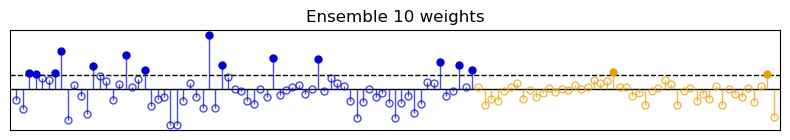

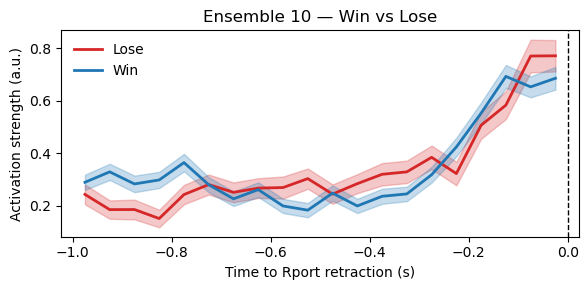

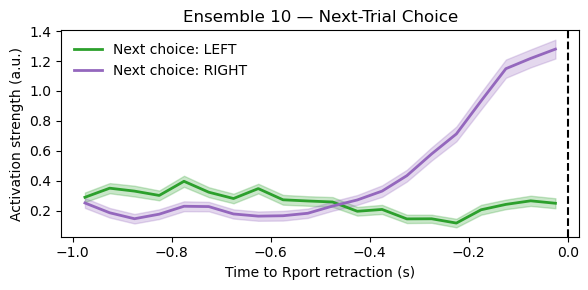

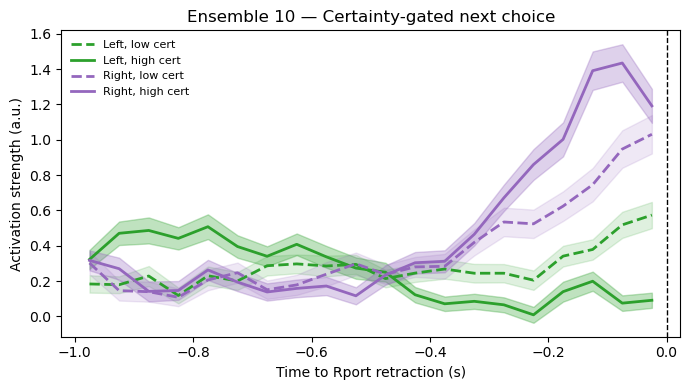

In [19]:
k = 10
plot_ensemble_weights(result, neuron_region, ensemble_id=k, membership_sd=1.0)
plot_ensemble_win_lose(
    R_quad,
    outcomes_all,
    ensemble_id=k
)
plot_ensemble_next_choice(R_quad, next_choices_all, ensemble_id=k)
plot_ensemble_choice_certainty_sessionwise(
    R_quad,
    next_choices_all,
    next_certainty_all,
    session_ids,
    ensemble_id=k
)

the above example ensemble: mPFC-dominated; predicting next choice (gated by certainty of the next choice)